# Chimera-2 dataset visualisation

This notebook explores `inputs.csv` (195 cases × clinical/imaging features + 1,024-dim MRI
embeddings) and `ground_truth.csv` (195 cases × the biopsy-decision labels and the per-factor
importance weights behind each decision).

**Structure**
1. Ground truth: biopsy decisions
2. Inputs: clinical & imaging features
3. Relating inputs to the decision
4. MRI embeddings (dimensionality reduction)

Run cells top to bottom — later cells reuse `gt`, `inp`, `df` and the palette defined early on.

In [ ]:
#%pip install scikit-learn

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [34]:
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import pandas as pd
import numpy as np

pd.set_option("display.max_columns", 30)

# --- palette (validated categorical / sequential / diverging set) ---
BLUE, ORANGE, AQUA, YELLOW = "#2a78d6", "#eb6834", "#1baf7a", "#eda100"
INK, INK2, MUTED, GRID, SURFACE = "#0b0b0b", "#52514e", "#898781", "#e1e0d9", "#fcfcfb"
GRAY_MID = "#f0efec"
SEQ_BLUE = ["#cde2fb", "#9ec5f4", "#5598e7", "#2a78d6", "#184f95"]   # light -> dark, magnitude
DECISION_COLOR = {"no": BLUE, "yes": ORANGE}                          # fixed categorical assignment

plt.rcParams.update({
    "figure.facecolor": SURFACE,
    "axes.facecolor": SURFACE,
    "savefig.facecolor": SURFACE,
    "axes.edgecolor": GRID,
    "axes.labelcolor": INK2,
    "text.color": INK,
    "xtick.color": MUTED,
    "ytick.color": MUTED,
    "axes.grid": True,
    "axes.axisbelow": True,
    "grid.color": GRID,
    "grid.linewidth": 0.8,
    "font.size": 10,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "figure.dpi": 110,
})

In [35]:
gt = pd.read_csv("data\\ground_truth.csv")
inp = pd.read_csv("data\\inputs.csv")

emb_cols = [c for c in inp.columns if c.startswith("mri_emb_")]
non_emb_cols = [c for c in inp.columns if c not in emb_cols]

df = inp.merge(gt, on="case_id", how="inner")

print(f"ground_truth.csv : {gt.shape}")
print(f"inputs.csv       : {inp.shape}  ({len(non_emb_cols)} clinical cols + {len(emb_cols)} MRI embedding dims)")
print(f"merged on case_id: {df.shape}")
df.head(3)

ground_truth.csv : (195, 27)
inputs.csv       : (195, 1077)  (53 clinical cols + 1024 MRI embedding dims)
merged on case_id: (195, 1103)


,case_id,cli_age,cli_psa,cli_psap,cli_psav,cli_psad,cli_vol,cli_months,cli_pirads,cli_dre,cli_bx,cli_cspca,cli_comorbidity_count,txt_comorbidities,cli_allergies_count,...,target_code_weight_pirads,target_weight_vol,target_code_weight_vol,target_weight_psa,target_code_weight_psa,target_weight_comorbidity,target_code_weight_comorbidity,target_weight_psad,target_code_weight_psad,target_weight_dre,target_code_weight_dre,target_weight_bx,target_code_weight_bx,target_reasoning_free_text,target_reveal_sequence_json
0,PT-pseudo_0020cfca66c8,67.0,4.7,4.4,0.48,0.140,33.46,2.0,2.0,Normal,Positive,0.596203,0.0,NaN,0.0,...,3.0,noted,1.0,important,2.0,noted,1.0,noted,1.0,noted,1.0,not_used,0.0,Priads 2 with only sightly elevated PSA,"[""radiology_report"", ""psa_trend"", ""laboratory_..."
1,PT-pseudo_0169468160c6,75.0,187.0,153.4,38.28,3.260,57.28,2.0,5.0,Nodus,Positive,0.964853,3.0,"Hypertension, Hypercholesterolaemia, Obesity (...",0.0,...,3.0,noted,1.0,decisive,3.0,noted,1.0,noted,1.0,noted,1.0,not_used,0.0,Very High PSA.\nMost likely metastatic,[]
2,PT-pseudo_01b643727538,71.0,9.3,8.6,-0.41,0.516,18.03,1.0,5.0,Normal,Positive,0.852476,0.0,NaN,0.0,...,2.0,noted,1.0,noted,1.0,noted,1.0,not_used,0.0,noted,1.0,decisive,3.0,He has a ISUP3 cancer diagnosis already and he...,"[""previous_notes"", ""laboratory_results"", ""psa_..."


`inputs.csv` on its own — 195 cases × 53 clinical/text columns + 1,024 MRI embedding dims:

In [36]:
inp

,case_id,cli_age,cli_psa,cli_psap,cli_psav,cli_psad,cli_vol,cli_months,cli_pirads,cli_dre,cli_bx,cli_cspca,cli_comorbidity_count,txt_comorbidities,cli_allergies_count,...,mri_emb_1009,mri_emb_1010,mri_emb_1011,mri_emb_1012,mri_emb_1013,mri_emb_1014,mri_emb_1015,mri_emb_1016,mri_emb_1017,mri_emb_1018,mri_emb_1019,mri_emb_1020,mri_emb_1021,mri_emb_1022,mri_emb_1023
0,PT-pseudo_0020cfca66c8,67.0,4.7,4.4,0.48,0.140,33.46,2.0,2.0,Normal,Positive,0.596203,0.0,NaN,0.0,...,-0.903427,0.534556,0.574917,-0.496588,-0.125448,1.332810,-0.063424,-0.987568,0.918697,-0.378079,-0.347853,0.156678,-0.828955,0.409984,0.316279
1,PT-pseudo_0169468160c6,75.0,187.0,153.4,38.28,3.260,57.28,2.0,5.0,Nodus,Positive,0.964853,3.0,"Hypertension, Hypercholesterolaemia, Obesity (...",0.0,...,-1.248357,1.372655,-0.091749,-0.553786,-1.540061,0.330011,0.816725,-1.770641,1.761632,-0.551952,0.437233,-0.112345,-1.537329,0.747816,-0.790656
2,PT-pseudo_01b643727538,71.0,9.3,8.6,-0.41,0.516,18.03,1.0,5.0,Normal,Positive,0.852476,0.0,NaN,0.0,...,-1.453929,1.714423,-0.099813,-0.347934,-1.175305,-0.210266,-0.830411,-2.132712,1.992791,-0.946260,0.024482,0.467739,-1.328886,0.638559,-1.815999
3,PT-pseudo_033f1a8e1503,60.0,5.9,4.1,1.83,0.199,29.71,1.0,5.0,Normal,NaN,0.842854,3.0,"Hypertension, Coronary artery disease, Benign ...",0.0,...,-0.502168,-0.358803,-0.977749,-0.037315,1.129759,1.388135,-1.355497,0.179132,-0.870553,-0.329961,-1.529732,-1.114914,-1.180692,-0.414328,0.163779
4,PT-pseudo_0615b2bd8504,63.0,160.0,115.9,35.73,2.635,60.71,1.0,5.0,Abnormal,Positive,0.958896,0.0,NaN,0.0,...,0.021157,2.240813,0.175042,-0.312276,-1.304761,-0.558415,0.014493,-1.638166,1.951232,0.127714,0.405779,0.211969,-0.413518,1.828876,-1.204237
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
190,PT-pseudo_fa31cd663f5a,66.0,4.1,3.5,0.74,0.130,31.00,1.0,4.0,Normal,Positive,0.861554,0.0,NaN,0.0,...,-0.943505,-0.147858,0.192533,-0.585329,-0.354179,1.684801,0.078274,-0.654262,1.698896,-0.280755,-0.254398,-0.169722,-0.889857,0.383410,0.010394
191,PT-pseudo_fa4a71ae9a34,65.0,4.8,3.6,1.05,0.190,25.31,2.0,5.0,Nodus,Positive,0.803558,0.0,NaN,0.0,...,-0.333207,0.687155,-0.010322,-0.162555,-0.655176,1.385482,0.299794,-1.034914,1.000547,-0.528214,-0.210908,0.546079,-1.315037,0.843687,-0.420855
192,PT-pseudo_fab43a43b7e6,56.0,4.3,3.2,0.99,0.174,24.74,2.0,4.0,Nodus,NaN,0.679332,0.0,NaN,0.0,...,0.126274,-2.291080,-0.990040,0.453094,-0.232172,1.700800,-0.147345,0.363773,0.099844,0.214509,-1.914846,-0.056586,-0.532875,-0.157049,0.612040
193,PT-pseudo_fc6cf5262222,61.0,7.5,4.6,1.49,0.179,42.00,1.0,4.0,Normal,Positive,0.000000,1.0,Hypertension,0.0,...,-0.590579,-1.679015,-0.073664,-0.548246,0.319643,0.784171,-0.612498,0.048068,-0.122139,-0.421023,-0.628015,-0.679862,-0.881294,-0.287580,0.358640


## 1. Ground truth: biopsy decisions

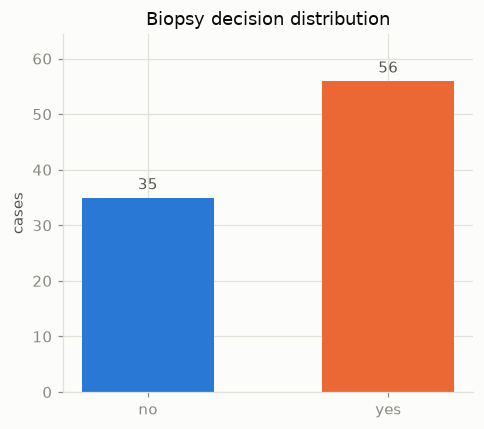

In [37]:
counts = gt["target_biopsy_decision"].value_counts().reindex(["no", "yes"])
fig, ax = plt.subplots(figsize=(4.5, 4))
ax.bar(counts.index, counts.values, color=[DECISION_COLOR[c] for c in counts.index], width=0.55)
for x, v in enumerate(counts.values):
    ax.text(x, v + 1.5, str(v), ha="center", color=INK2, fontsize=10)
ax.set_ylabel("cases")
ax.set_title("Biopsy decision distribution")
ax.set_ylim(0, counts.max() * 1.15)
fig.tight_layout()

target_confidence is unset for 104/195 cases (53%) — not plotted above.


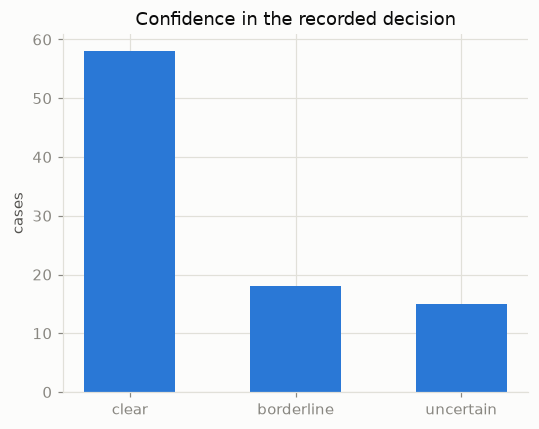

In [38]:
conf_order = ["clear", "borderline", "uncertain"]
n_missing_conf = gt["target_confidence"].isna().sum()
conf_counts = gt["target_confidence"].value_counts().reindex(conf_order)

fig, ax = plt.subplots(figsize=(5, 4))
ax.bar(conf_counts.index, conf_counts.values, color=SEQ_BLUE[3], width=0.55)
ax.set_ylabel("cases")
ax.set_title("Confidence in the recorded decision")
fig.tight_layout()

print(f"target_confidence is unset for {n_missing_conf}/{len(gt)} cases "
      f"({n_missing_conf / len(gt):.0%}) — not plotted above.")

Each decision *can* be explained by ten weighted factors (age, family history, csPCa risk score,
PI-RADS, prostate volume, PSA, comorbidity, PSAD, DRE, prior biopsy) each coded on an ordinal
scale — `not_used` (0) → `noted` (1) → `important` (2) → `decisive` (3). But only **91 of 195**
cases carry this breakdown — the same 104 cases missing `target_confidence` are also missing
every `target_weight_*` column and the free-text reasoning, i.e. roughly half the dataset has a
bare yes/no with no explanation attached. The chart below is computed over the 91 annotated
cases only, ranked by how often each factor is decisive.

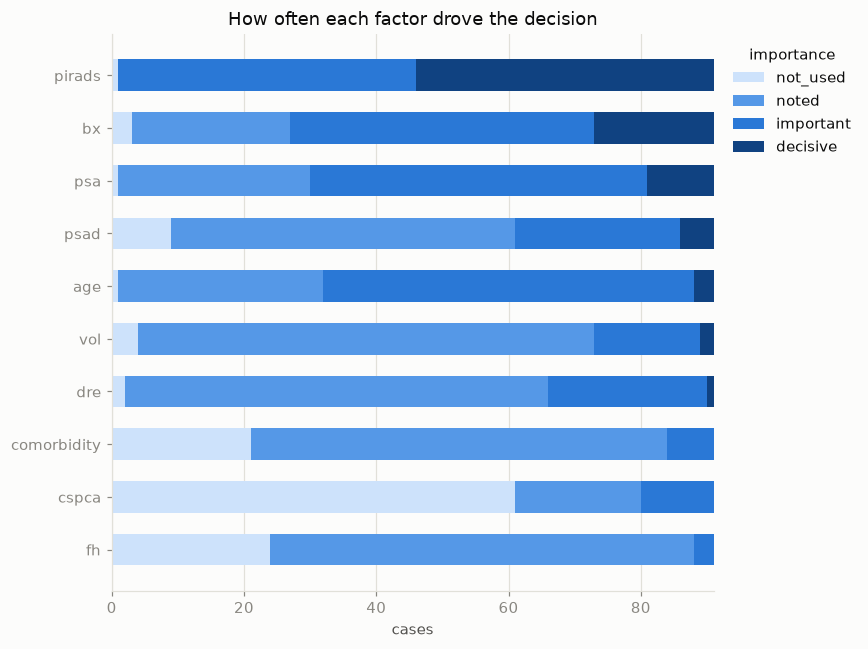

In [39]:
levels = ["not_used", "noted", "important", "decisive"]
factor_cols = [c for c in gt.columns if c.startswith("target_weight_")]
factor_labels = [c.replace("target_weight_", "") for c in factor_cols]

level_counts = pd.DataFrame(
    {label: gt[col].value_counts().reindex(levels).fillna(0) for label, col in zip(factor_labels, factor_cols)}
).T
level_counts = level_counts.loc[level_counts["decisive"].sort_values().index]  # rank by "decisive" freq

level_colors = [SEQ_BLUE[0], SEQ_BLUE[2], SEQ_BLUE[3], "#104281"]  # not_used -> decisive, light to dark

fig, ax = plt.subplots(figsize=(8, 6))
left = np.zeros(len(level_counts))
for lvl, color in zip(levels, level_colors):
    ax.barh(level_counts.index, level_counts[lvl], left=left, color=color, label=lvl, height=0.6)
    left += level_counts[lvl].values
ax.set_xlabel("cases")
ax.set_title("How often each factor drove the decision")
ax.legend(title="importance", loc="upper left", bbox_to_anchor=(1.01, 1), frameon=False)
fig.tight_layout()

## 2. Inputs: clinical & imaging features

1024 MRI embedding columns are entirely present except for 4 cases with a fully-missing 1024-dim vector (no MRI available).


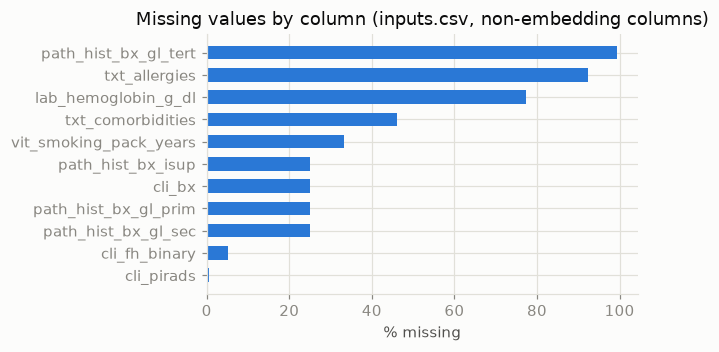

In [40]:
miss = inp[non_emb_cols].isna().mean().sort_values(ascending=False)
miss = miss[miss > 0] * 100

fig, ax = plt.subplots(figsize=(6, max(3, 0.3 * len(miss))))
ax.barh(miss.index[::-1], miss.values[::-1], color=SEQ_BLUE[3], height=0.6)
ax.set_xlabel("% missing")
ax.set_title("Missing values by column (inputs.csv, non-embedding columns)")
fig.tight_layout()

print(f"{len(emb_cols)} MRI embedding columns are entirely present except for "
      f"{inp[emb_cols].isna().any(axis=1).sum()} cases with a fully-missing 1024-dim vector "
      f"(no MRI available).")

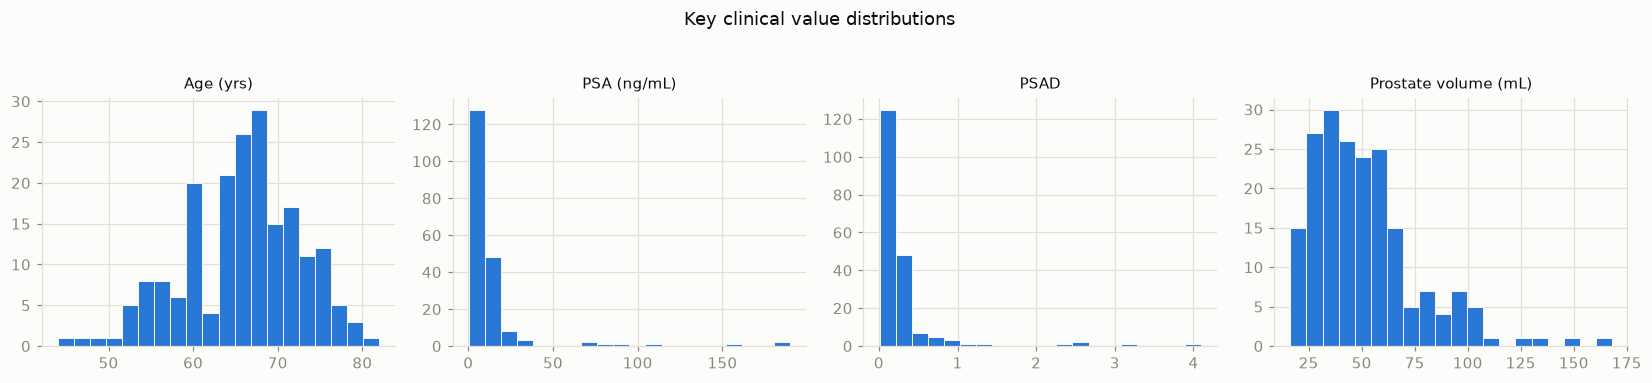

In [41]:
num_cols = ["cli_age", "cli_psa", "cli_psad", "cli_vol"]
titles = ["Age (yrs)", "PSA (ng/mL)", "PSAD", "Prostate volume (mL)"]

fig, axes = plt.subplots(1, 4, figsize=(15, 3.3))
for ax, col, title in zip(axes, num_cols, titles):
    ax.hist(inp[col].dropna(), bins=20, color=BLUE, edgecolor=SURFACE, linewidth=0.6)
    ax.set_title(title, color=INK, fontsize=10)
fig.suptitle("Key clinical value distributions", y=1.04)
fig.tight_layout()

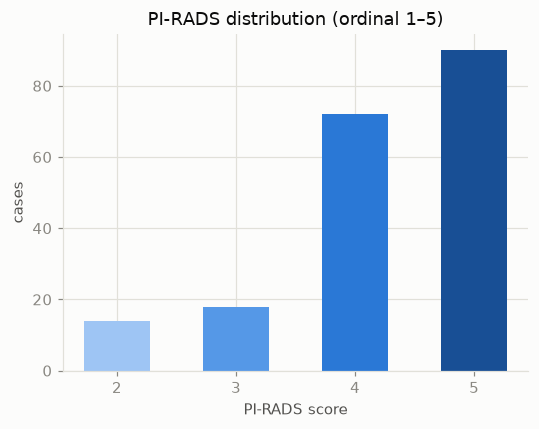

In [42]:
pirads_counts = inp["cli_pirads"].value_counts().sort_index()
colors = [SEQ_BLUE[min(int(i) - 1, len(SEQ_BLUE) - 1)] for i in pirads_counts.index]

fig, ax = plt.subplots(figsize=(5, 4))
ax.bar(pirads_counts.index.astype(int).astype(str), pirads_counts.values, color=colors, width=0.55)
ax.set_xlabel("PI-RADS score")
ax.set_ylabel("cases")
ax.set_title("PI-RADS distribution (ordinal 1–5)")
fig.tight_layout()

## 3. Relating inputs to the decision

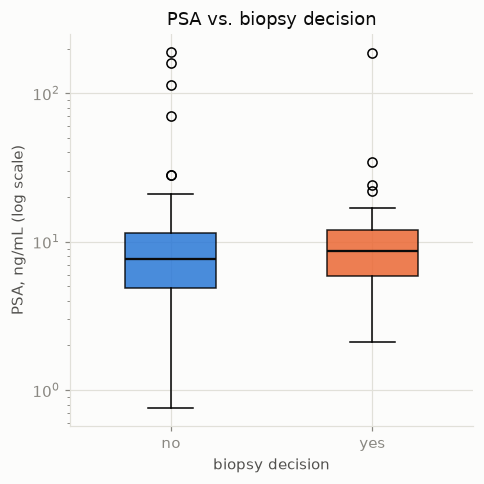

In [43]:
fig, ax = plt.subplots(figsize=(4.5, 4.5))
data = [df.loc[df.target_biopsy_decision == d, "cli_psa"].dropna() for d in ["no", "yes"]]
bp = ax.boxplot(data, tick_labels=["no", "yes"], patch_artist=True, widths=0.45,
                 medianprops=dict(color=INK, linewidth=1.5))
for patch, d in zip(bp["boxes"], ["no", "yes"]):
    patch.set_facecolor(DECISION_COLOR[d])
    patch.set_alpha(0.85)
ax.set_yscale("log")
ax.set_ylabel("PSA, ng/mL (log scale)")
ax.set_xlabel("biopsy decision")
ax.set_title("PSA vs. biopsy decision")
fig.tight_layout()

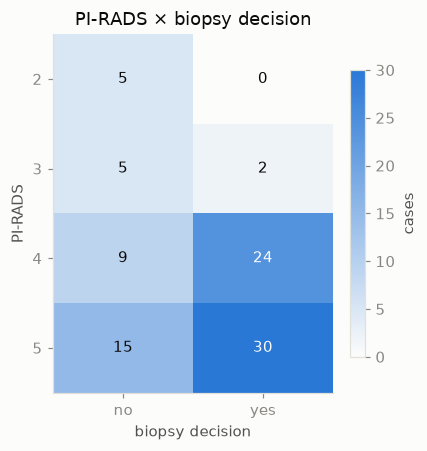

In [44]:
ct = pd.crosstab(df["cli_pirads"].astype("Int64"), df["target_biopsy_decision"])[["no", "yes"]]
cmap = mcolors.LinearSegmentedColormap.from_list("seq_blue", [SURFACE, BLUE])

fig, ax = plt.subplots(figsize=(4, 4.2))
im = ax.imshow(ct.values, cmap=cmap, aspect="auto")
ax.set_xticks(range(len(ct.columns)))
ax.set_xticklabels(ct.columns)
ax.set_yticks(range(len(ct.index)))
ax.set_yticklabels(ct.index)
ax.set_xlabel("biopsy decision")
ax.set_ylabel("PI-RADS")
ax.grid(False)
vmax = ct.values.max()
for i in range(ct.shape[0]):
    for j in range(ct.shape[1]):
        v = ct.values[i, j]
        ax.text(j, i, str(v), ha="center", va="center",
                 color=SURFACE if v > vmax / 2 else INK, fontsize=10)
ax.set_title("PI-RADS × biopsy decision")
fig.colorbar(im, ax=ax, shrink=0.8, label="cases")
fig.tight_layout()

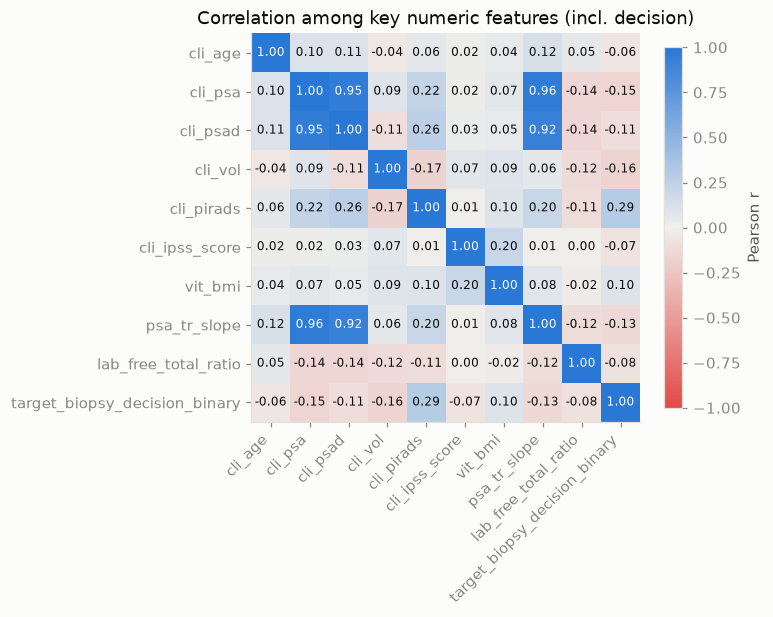

In [45]:
num_feature_cols = ["cli_age", "cli_psa", "cli_psad", "cli_vol", "cli_pirads",
                     "cli_ipss_score", "vit_bmi", "psa_tr_slope", "lab_free_total_ratio",
                     "target_biopsy_decision_binary"]
corr = df[num_feature_cols].corr()
cmap = mcolors.LinearSegmentedColormap.from_list("diverging", ["#e34948", GRAY_MID, BLUE])

fig, ax = plt.subplots(figsize=(7, 6))
im = ax.imshow(corr.values, cmap=cmap, vmin=-1, vmax=1)
ax.set_xticks(range(len(num_feature_cols)))
ax.set_xticklabels(num_feature_cols, rotation=45, ha="right")
ax.set_yticks(range(len(num_feature_cols)))
ax.set_yticklabels(num_feature_cols)
ax.grid(False)
for i in range(corr.shape[0]):
    for j in range(corr.shape[1]):
        ax.text(j, i, f"{corr.values[i, j]:.2f}", ha="center", va="center",
                 color=INK if abs(corr.values[i, j]) < 0.6 else SURFACE, fontsize=8)
ax.set_title("Correlation among key numeric features (incl. decision)")
fig.colorbar(im, ax=ax, shrink=0.8, label="Pearson r")
fig.tight_layout()

## 4. MRI embeddings

Each case carries a 1,024-dimensional MRI embedding (`mri_emb_0` … `mri_emb_1023`). A handful of
cases have no MRI at all — their embedding is entirely `NaN` — so those are dropped before the
projection below. We reduce to 2D with PCA and color by the biopsy decision to see whether the
embedding space alone separates the two outcomes.

Dropped 4 case(s) with no MRI embedding; 191 remain.


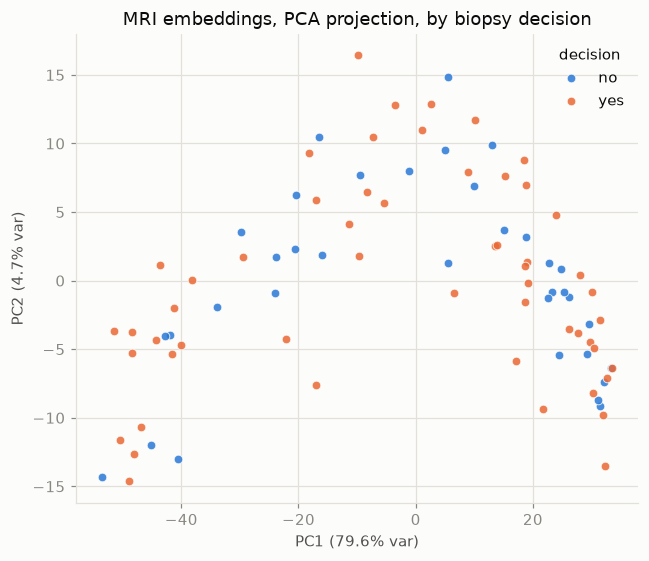

In [46]:
from sklearn.decomposition import PCA
#from umap import umap

missing_mri = df[emb_cols].isna().any(axis=1)
sub = df.loc[~missing_mri]
print(f"Dropped {missing_mri.sum()} case(s) with no MRI embedding; {len(sub)} remain.")

pca = PCA(n_components=2, random_state=0)
coords = pca.fit_transform(sub[emb_cols].values)

fig, ax = plt.subplots(figsize=(6, 5.2))
for d in ["no", "yes"]:
    mask = (sub["target_biopsy_decision"] == d).values
    ax.scatter(coords[mask, 0], coords[mask, 1], color=DECISION_COLOR[d], label=d,
               s=32, alpha=0.85, edgecolor=SURFACE, linewidth=0.6)
ax.set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]:.1%} var)")
ax.set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]:.1%} var)")
ax.set_title("MRI embeddings, PCA projection, by biopsy decision")
ax.legend(title="decision", frameon=False)
fig.tight_layout()

## Next steps

- Confirm `case_id` matches 1:1 between the two files (no orphaned rows on either side).
- Check whether PC1 (~most of the embedding variance) correlates with PI-RADS or csPCa score —
  it may just be encoding lesion conspicuity.
- Try a supervised split (t-SNE/UMAP, or a simple classifier + SHAP) on the embeddings against
  `target_biopsy_decision_binary` to see whether imaging alone predicts the recorded decision,
  versus how much the clinical factors (PSA, PSAD, age, comorbidity) add.

## 5. Input variable inventory — what's usable for modeling

`inputs.csv` has 53 non-embedding columns beyond the 1,024 MRI dims already explored in section 4.
Before feeding any of them to a model it helps to know, per column: what **group** it belongs to
(clinical / vitals / labs / PSA-trend / pathology-history / free text), what **kind** it behaves
like (identifier, binary, ordinal, continuous, categorical, or free text), how much is **missing**,
and how it **relates to the recorded decision** — each implies a different preprocessing choice
(one-hot vs. ordinal-encode vs. impute-with-indicator vs. drop vs. a separate NLP pipeline).

In [47]:
GROUP_PREFIXES = [
    ("txt_", "free text"),
    ("cli_", "clinical"),
    ("vit_", "vitals"),
    ("lab_", "labs"),
    ("psa_tr_", "psa trend (derived)"),
    ("path_hist_", "pathology history"),
]

def classify_group(col):
    if col == "case_id":
        return "identifier"
    for prefix, group in GROUP_PREFIXES:
        if col.startswith(prefix):
            return group
    return "other"

def classify_kind(col, s):
    if col == "case_id":
        return "identifier"
    non_null = s.dropna()
    nu = non_null.nunique()
    if pd.api.types.is_numeric_dtype(s):
        if nu <= 2:
            return "binary"
        elif nu <= 10:
            return "ordinal / discrete"
        return "continuous"
    return "categorical" if nu <= 10 else "free text"

inventory = pd.DataFrame({
    "column": non_emb_cols,
    "group": [classify_group(c) for c in non_emb_cols],
    "dtype": [str(inp[c].dtype) for c in non_emb_cols],
    "kind": [classify_kind(c, inp[c]) for c in non_emb_cols],
    "n_unique": [inp[c].nunique(dropna=True) for c in non_emb_cols],
    "pct_missing": [round(inp[c].isna().mean() * 100, 1) for c in non_emb_cols],
})
inventory["near_constant"] = inventory["n_unique"] <= 1
inventory = inventory.sort_values(["group", "pct_missing"], ascending=[True, False]).reset_index(drop=True)

print(f"{len(non_emb_cols)} non-embedding columns across {inventory['group'].nunique()} groups; "
      f"{inventory['near_constant'].sum()} near-constant column(s) flagged.")
inventory

53 non-embedding columns across 7 groups; 1 near-constant column(s) flagged.


,column,group,dtype,kind,n_unique,pct_missing,near_constant
0,cli_bx,clinical,str,categorical,2,25.1,False
1,cli_fh_binary,clinical,float64,binary,2,5.1,False
2,cli_pirads,clinical,float64,ordinal / discrete,4,0.5,False
3,cli_age,clinical,float64,continuous,33,0.0,False
4,cli_psa,clinical,float64,continuous,119,0.0,False
5,cli_psap,clinical,float64,continuous,109,0.0,False
6,cli_psav,clinical,float64,continuous,151,0.0,False
7,cli_psad,clinical,float64,continuous,124,0.0,False
8,cli_vol,clinical,float64,continuous,163,0.0,False
9,cli_months,clinical,float64,ordinal / discrete,3,0.0,False


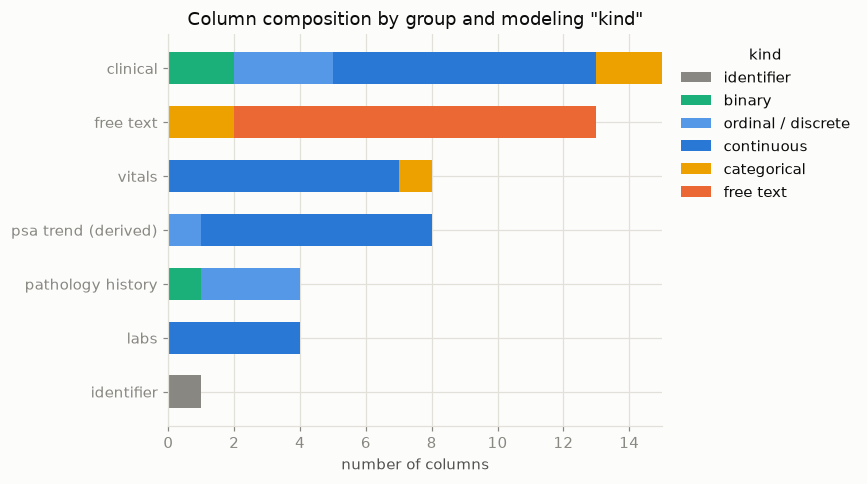

In [48]:
kind_order = ["identifier", "binary", "ordinal / discrete", "continuous", "categorical", "free text"]
kind_colors = {
    "identifier": MUTED,
    "binary": AQUA,
    "ordinal / discrete": SEQ_BLUE[2],
    "continuous": BLUE,
    "categorical": YELLOW,
    "free text": ORANGE,
}

comp = (inventory.groupby(["group", "kind"]).size()
        .unstack(fill_value=0).reindex(columns=kind_order, fill_value=0))
comp = comp.loc[comp.sum(axis=1).sort_values().index]

fig, ax = plt.subplots(figsize=(8, 4.5))
left = np.zeros(len(comp))
for kind in kind_order:
    vals = comp[kind].values
    ax.barh(comp.index, vals, left=left, color=kind_colors[kind], label=kind, height=0.6)
    left += vals
ax.set_xlabel("number of columns")
ax.set_title("Column composition by group and modeling \"kind\"")
ax.legend(title="kind", loc="upper left", bbox_to_anchor=(1.01, 1), frameon=False)
fig.tight_layout()

Free text dominates the column count (11 of 53) but most of it restates a structured column
already present elsewhere (e.g. `txt_comorbidities` vs. `cli_comorbidity_count`,
`txt_psa_trend_summary` vs. the six `psa_tr_*` columns) — it needs its own NLP path (TF-IDF,
embeddings) to be usable and isn't required for a first tabular baseline. The remaining ~40
structured columns split into:

- **binary** — already 0/1-ish, just cast and use directly
- **ordinal / discrete** — small ordered integer sets (e.g. PI-RADS 1–5); encode as ordered
  integers, not one-hot, to keep the ordering signal
- **continuous** — numeric measurements; impute + scale as usual
- **categorical** — a handful of low-cardinality text columns; one-hot or target-encode

Next: look at the categorical columns' actual categories, then the continuous columns' summary
stats and correlation with the decision.

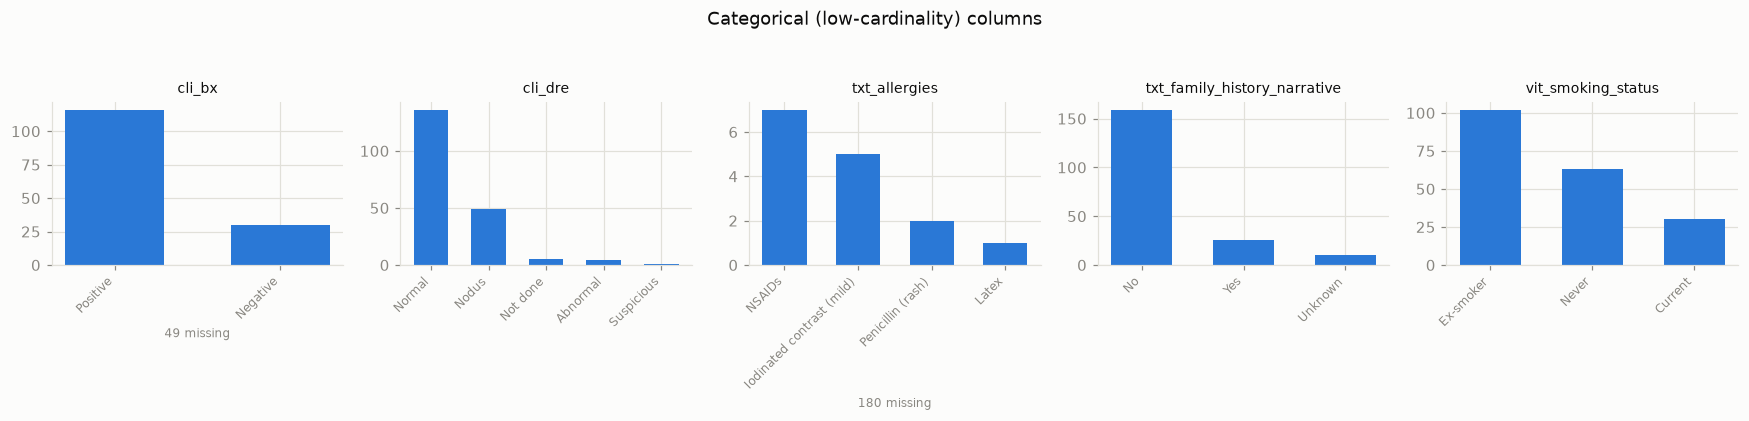

In [49]:
cat_cols = inventory.loc[inventory["kind"] == "categorical", "column"].tolist()

fig, axes = plt.subplots(1, len(cat_cols), figsize=(3.2 * len(cat_cols), 3.6))
for ax, col in zip(axes, cat_cols):
    vc = inp[col].value_counts()
    ax.bar(range(len(vc)), vc.values, color=SEQ_BLUE[3], width=0.6)
    ax.set_xticks(range(len(vc)))
    ax.set_xticklabels(vc.index.astype(str), rotation=45, ha="right", fontsize=8)
    ax.set_title(col, fontsize=9)
    n_missing = inp[col].isna().sum()
    if n_missing:
        ax.set_xlabel(f"{n_missing} missing", fontsize=8, color=MUTED)
fig.suptitle("Categorical (low-cardinality) columns", y=1.05)
fig.tight_layout()

In [50]:
cont_cols = inventory.loc[inventory["kind"] == "continuous", "column"].tolist()
inp[cont_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
cli_age,195.0,65.717949,6.838900,44.0000,61.000000,66.000000,70.500000,82.000000
cli_psa,195.0,13.712308,24.764294,0.2000,5.450000,7.800000,12.000000,190.000000
cli_psap,195.0,11.017436,18.906212,0.4000,4.200000,6.200000,10.150000,153.400000
cli_psav,195.0,2.489026,5.156258,-0.7800,0.770000,1.370000,2.125000,41.570000
cli_psad,195.0,0.293113,0.487675,0.0080,0.110000,0.177000,0.270000,4.097000
cli_vol,195.0,51.354513,25.120681,16.4000,32.670000,46.380000,61.000000,168.000000
cli_cspca,195.0,0.737073,0.178722,0.0000,0.699203,0.791974,0.847336,0.971879
cli_ipss_score,195.0,9.461538,7.920501,0.0000,3.000000,7.000000,14.500000,34.000000
lab_hemoglobin_g_dl,44.0,6.040909,0.345952,5.4000,5.800000,6.100000,6.300000,6.600000
lab_creatinine_mg_dl,195.0,96.123077,17.787556,72.0000,86.000000,91.000000,102.000000,173.000000


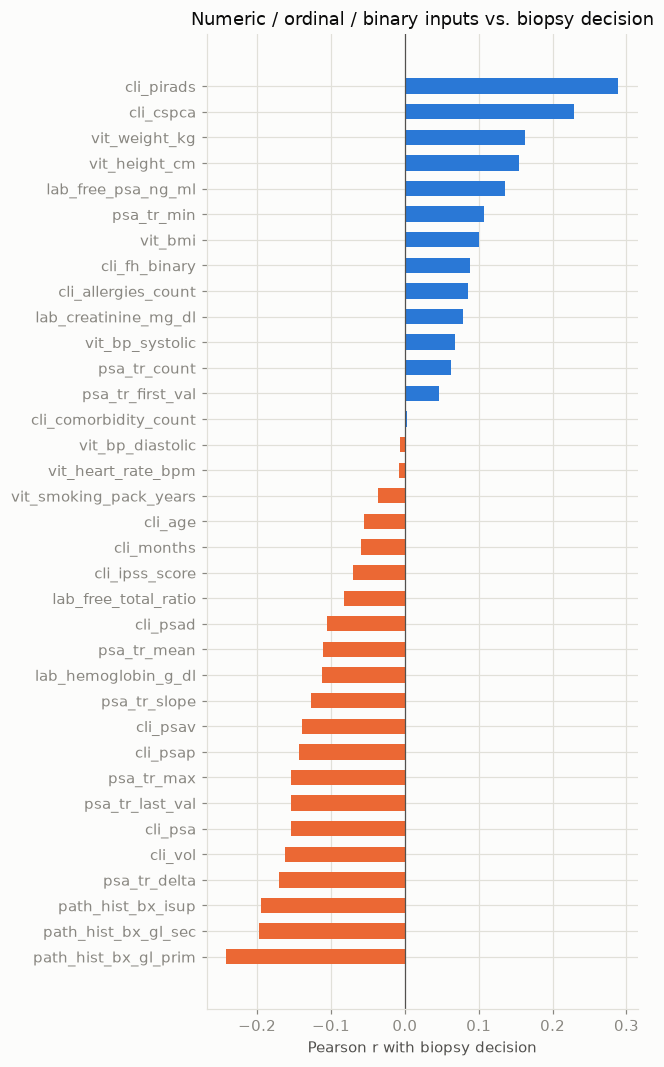

In [51]:
target_col = "target_biopsy_decision_binary"
num_cols_for_corr = inventory.loc[
    inventory["kind"].isin(["continuous", "ordinal / discrete", "binary"]), "column"
].tolist()

corr_target = df[num_cols_for_corr + [target_col]].corr()[target_col].drop(target_col).dropna().sort_values()
colors = [BLUE if v >= 0 else ORANGE for v in corr_target.values]

fig, ax = plt.subplots(figsize=(6, max(4, 0.28 * len(corr_target))))
ax.barh(corr_target.index, corr_target.values, color=colors, height=0.6)
ax.axvline(0, color=INK2, linewidth=0.8)
ax.set_xlabel("Pearson r with biopsy decision")
ax.set_title("Numeric / ordinal / binary inputs vs. biopsy decision")
fig.tight_layout()

### Modeling recommendations

- **Drop as a feature:** `case_id` (join key only) and `path_hist_bx_gl_tert` (99.5% missing, a
  single unique value once present — no signal, flagged `near_constant` above).
- **Free text (11 columns):** mostly restates a structured column already covered elsewhere
  (`txt_comorbidities` ↔ `cli_comorbidity_count`, `txt_psa_trend_summary`/`txt_laboratory_results_summary`
  ↔ the `psa_tr_*`/`lab_*` columns, `txt_consolidated_ehr_narrative` ↔ nearly everything). Leave
  these out of a first tabular baseline; if you want to use them, they need a separate NLP
  pipeline (TF-IDF or a text embedding), not one-hot encoding.
- **Ordinal / discrete** (`cli_pirads`, `cli_comorbidity_count`, `cli_months`,
  `path_hist_bx_isup`, `path_hist_bx_gl_prim`, `path_hist_bx_gl_sec`): encode as ordered integers
  — section 3 already showed PI-RADS has a clear monotonic relationship with the decision, which
  one-hot encoding would throw away.
- **Binary** (`cli_fh_binary`, `cli_allergies_count`): already numeric 0/1, cast directly.
- **Categorical** (`cli_dre`, `cli_bx`, `vit_smoking_status`, `txt_family_history_narrative`,
  `txt_allergies`): text-valued but low-cardinality — one-hot or target-encode. `cli_bx` only
  takes two non-null values (prior biopsy positive/negative) but is still object-dtype, so it
  needs the same string→category mapping as the others. Keep an explicit "missing" category
  rather than imputing, since missingness itself may be informative (e.g. `txt_allergies` is 92%
  missing — likely "none recorded" rather than unknown).
- **Continuous:** impute (median is a reasonable default given the skewed PSA-family
  distributions) and add a missingness indicator for the higher-missing ones —
  `lab_hemoglobin_g_dl` (77%), `vit_smoking_pack_years` (33%). Watch for multicollinearity within
  families derived from the same underlying measurement: `cli_psa`/`cli_psap`/`cli_psav`/`cli_psad`
  all come from the same PSA value, and the six `psa_tr_*` columns all come from the same PSA
  trend — fine for tree-based models, but a linear model may want one representative per family
  or L2 regularization.
- **Leakage check before using `path_hist_*`:** these are *prior*-biopsy pathology results
  (ISUP grade, Gleason pattern), missing for the same ~25% of cases as `cli_bx` — i.e. populated
  exactly when a prior biopsy exists, which is historical context available *before* the current
  decision, not an outcome of it. Legitimate to use, but confirm that assumption holds for your
  use case before trusting it.
- **`cli_cspca` is already an aggregate risk score** — it's one of the ten named decision factors
  from section 1, not a raw measurement. A model that leans on it heavily may just be re-deriving
  the clinician's own risk calculator; worth comparing performance with and without it to see how
  much the *other* clinical variables (age, comorbidity, PSAD) contribute on top.

In [52]:
inp.iloc[:,:53]

,case_id,cli_age,cli_psa,cli_psap,cli_psav,cli_psad,cli_vol,cli_months,cli_pirads,cli_dre,cli_bx,cli_cspca,cli_comorbidity_count,txt_comorbidities,cli_allergies_count,...,psa_tr_count,psa_tr_first_val,psa_tr_last_val,psa_tr_min,psa_tr_max,psa_tr_mean,psa_tr_delta,psa_tr_slope,txt_psa_trend_summary,lab_creatinine_mg_dl,lab_hemoglobin_g_dl,lab_free_psa_ng_ml,lab_free_total_ratio,txt_laboratory_results_summary,txt_consolidated_ehr_narrative
0,PT-pseudo_0020cfca66c8,67.0,4.7,4.4,0.48,0.140,33.46,2.0,2.0,Normal,Positive,0.596203,0.0,NaN,0.0,...,4.0,4.2,4.7,0.6,4.7,3.075000,0.5,0.166667,Feb 2022: 4.2 | Feb 2023: 2.8 | Jan 2024: 0.6 ...,94.0,NaN,26.0,5.531915,PSA: 4.7 ng/mL | Free PSA: 1.21 ng/mL | %Free ...,Chief complaint: Specialist reassessment sough...
1,PT-pseudo_0169468160c6,75.0,187.0,153.4,38.28,3.260,57.28,2.0,5.0,Nodus,Positive,0.964853,3.0,"Hypertension, Hypercholesterolaemia, Obesity (...",0.0,...,3.0,12.4,187.0,3.3,187.0,67.566667,174.6,87.300000,Jan 2024: 12.4 | Aug 2024: 3.3 | Feb 2025: 187.0,108.0,5.5,19.0,0.101604,PSA: 187.0 ng/mL | Free PSA: 34.88 ng/mL | %Fr...,Chief complaint: A pronounced upward trajector...
2,PT-pseudo_01b643727538,71.0,9.3,8.6,-0.41,0.516,18.03,1.0,5.0,Normal,Positive,0.852476,0.0,NaN,0.0,...,3.0,5.8,9.3,3.1,9.3,6.066667,3.5,1.750000,Nov 2023: 5.8 | Jun 2024: 3.1 | Feb 2025: 9.3,108.0,NaN,12.0,1.290323,PSA: 9.3 ng/mL | Free PSA: 1.08 ng/mL | %Free ...,Chief complaint: Assessment needed due to prev...
3,PT-pseudo_033f1a8e1503,60.0,5.9,4.1,1.83,0.199,29.71,1.0,5.0,Normal,NaN,0.842854,3.0,"Hypertension, Coronary artery disease, Benign ...",0.0,...,3.0,4.2,5.9,3.4,5.9,4.500000,1.7,0.850000,Apr 2022: 4.2 | Sep 2023: 3.4 | Jan 2025: 5.9,96.0,5.9,16.0,2.711864,PSA: 5.9 ng/mL | Free PSA: 0.93 ng/mL | %Free ...,Chief complaint: Routine monitoring after mpMR...
4,PT-pseudo_0615b2bd8504,63.0,160.0,115.9,35.73,2.635,60.71,1.0,5.0,Abnormal,Positive,0.958896,0.0,NaN,0.0,...,4.0,14.8,160.0,12.0,160.0,51.425000,145.2,48.400000,Aug 2022: 14.8 | Jun 2023: 18.9 | Apr 2024: 12...,72.0,NaN,10.0,0.062500,PSA: 160.0 ng/mL | Free PSA: 16.71 ng/mL | %Fr...,Chief complaint: Persistent elevation in PSA l...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
190,PT-pseudo_fa31cd663f5a,66.0,4.1,3.5,0.74,0.130,31.00,1.0,4.0,Normal,Positive,0.861554,0.0,NaN,0.0,...,5.0,3.4,4.1,0.7,4.1,2.640000,0.7,0.175000,Jun 2022: 3.4 | Feb 2023: 2.4 | Oct 2023: 0.7 ...,94.0,NaN,21.0,5.121951,PSA: 4.1 ng/mL | Free PSA: 0.88 ng/mL | %Free ...,Chief complaint: Clinical review requested aft...
191,PT-pseudo_fa4a71ae9a34,65.0,4.8,3.6,1.05,0.190,25.31,2.0,5.0,Nodus,Positive,0.803558,0.0,NaN,0.0,...,4.0,1.2,4.8,1.2,4.8,3.550000,3.6,1.200000,Jun 2023: 1.2 | Dec 2023: 4.6 | Jul 2024: 3.6 ...,101.0,NaN,11.0,2.291667,PSA: 4.8 ng/mL | Free PSA: 0.54 ng/mL | %Free ...,Chief complaint: Rising prostate-specific anti...
192,PT-pseudo_fab43a43b7e6,56.0,4.3,3.2,0.99,0.174,24.74,2.0,4.0,Nodus,NaN,0.679332,0.0,NaN,0.0,...,4.0,1.2,4.3,0.9,4.3,2.675000,3.1,1.033333,Aug 2023: 1.2 | Jan 2024: 0.9 | Jul 2024: 4.3 ...,87.0,NaN,28.0,6.511628,PSA: 4.3 ng/mL | Free PSA: 1.19 ng/mL | %Free ...,Chief complaint: Current evaluation triggered ...
193,PT-pseudo_fc6cf5262222,61.0,7.5,4.6,1.49,0.179,42.00,1.0,4.0,Normal,Positive,0.000000,1.0,Hypertension,0.0,...,4.0,2.9,7.5,2.9,7.5,4.975000,4.6,1.533333,Nov 2022: 2.9 | Aug 2023: 4.0 | May 2024: 5.5 ...,85.0,6.2,22.0,2.933333,PSA: 7.5 ng/mL | Free PSA: 1.68 ng/mL | %Free ...,Chief complaint: Clinical reassessment trigger...


In [53]:
for i in inp.columns:
    print(i)

case_id
cli_age
cli_psa
cli_psap
cli_psav
cli_psad
cli_vol
cli_months
cli_pirads
cli_dre
cli_bx
cli_cspca
cli_comorbidity_count
txt_comorbidities
cli_allergies_count
txt_allergies
cli_ipss_score
vit_weight_kg
vit_height_cm
vit_bmi
vit_bp_systolic
vit_bp_diastolic
vit_heart_rate_bpm
vit_smoking_status
vit_smoking_pack_years
path_hist_bx_isup
path_hist_bx_gl_prim
path_hist_bx_gl_sec
path_hist_bx_gl_tert
txt_chief_complaint
txt_history
txt_physical_examination
txt_prompt_summary_notes
txt_full_prompt_narrative
cli_fh_binary
txt_family_history_narrative
txt_radiology_report
txt_previous_notes
psa_tr_count
psa_tr_first_val
psa_tr_last_val
psa_tr_min
psa_tr_max
psa_tr_mean
psa_tr_delta
psa_tr_slope
txt_psa_trend_summary
lab_creatinine_mg_dl
lab_hemoglobin_g_dl
lab_free_psa_ng_ml
lab_free_total_ratio
txt_laboratory_results_summary
txt_consolidated_ehr_narrative
mri_emb_0
mri_emb_1
mri_emb_2
mri_emb_3
mri_emb_4
mri_emb_5
mri_emb_6
mri_emb_7
mri_emb_8
mri_emb_9
mri_emb_10
mri_emb_11
mri_emb_12


In [65]:
inp.iloc[:,:10]

,case_id,cli_age,cli_psa,cli_psap,cli_psav,cli_psad,cli_vol,cli_months,cli_pirads,cli_dre
0,PT-pseudo_0020cfca66c8,67.0,4.7,4.4,0.48,0.140,33.46,2.0,2.0,Normal
1,PT-pseudo_0169468160c6,75.0,187.0,153.4,38.28,3.260,57.28,2.0,5.0,Nodus
2,PT-pseudo_01b643727538,71.0,9.3,8.6,-0.41,0.516,18.03,1.0,5.0,Normal
3,PT-pseudo_033f1a8e1503,60.0,5.9,4.1,1.83,0.199,29.71,1.0,5.0,Normal
4,PT-pseudo_0615b2bd8504,63.0,160.0,115.9,35.73,2.635,60.71,1.0,5.0,Abnormal
...,...,...,...,...,...,...,...,...,...,...
190,PT-pseudo_fa31cd663f5a,66.0,4.1,3.5,0.74,0.130,31.00,1.0,4.0,Normal
191,PT-pseudo_fa4a71ae9a34,65.0,4.8,3.6,1.05,0.190,25.31,2.0,5.0,Nodus
192,PT-pseudo_fab43a43b7e6,56.0,4.3,3.2,0.99,0.174,24.74,2.0,4.0,Nodus
193,PT-pseudo_fc6cf5262222,61.0,7.5,4.6,1.49,0.179,42.00,1.0,4.0,Normal
